In [ ]:
# ============================================
# DEPENDENCY INSTALLATION
# ============================================
# Install required packages for marine debris detection training
# Run this cell once to set up the environment

!pip install pycocotools ultralytics albumentations opencv-python matplotlib seaborn pandas numpy tqdm pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.3 MB/s eta 0:00:00


In [ ]:
# ============================================
# IMPORTS AND DATA LOADING
# ============================================
# Import required libraries for data processing and model training
# Mount Google Drive to access the marine debris dataset

import os
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
from pycocotools import mask as maskUtils
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import shutil
import random
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive for dataset access
from google.colab import drive
drive.mount('/content/drive')

# ============================================
# DATASET PATHS CONFIGURATION
# ============================================
# Set paths for training and test data
# Update these paths according to your dataset location

BASE_PATH = "/content/drive/My Drive/Marine-DebrisDataset"
TRAIN_IMG_PATH = os.path.join(BASE_PATH, "train")
TEST_IMG_PATH = os.path.join(BASE_PATH, "test")
TRAIN_ANNOTATIONS = os.path.join(TRAIN_IMG_PATH, "annotations.json")
TEST_ANNOTATIONS = os.path.join(TEST_IMG_PATH, "annotations.json")

# ============================================
# COCO ANNOTATION LOADING
# ============================================
# Load COCO format annotations for training and test sets
# COCO format is a standard annotation format for object detection

def load_coco_annotations(annotation_path):
    """
    Load COCO format annotations from JSON file
    
    Args:
        annotation_path: Path to annotations.json file
        
    Returns:
        Dictionary containing COCO annotation data
    """
    with open(annotation_path, 'r') as f:
        coco_data = json.load(f)
    return coco_data

# Load training and test annotations
train_coco = load_coco_annotations(TRAIN_ANNOTATIONS)
test_coco = load_coco_annotations(TEST_ANNOTATIONS)

# Display dataset statistics
print(f"Training images: {len(train_coco['images'])}")
print(f"Training annotations: {len(train_coco['annotations'])}")
print(f"Test images: {len(test_coco['images'])}")
print(f"Test annotations: {len(test_coco['annotations'])}")
print(f"Categories: {len(train_coco['categories'])}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training images: 570
Training annotations: 1703
Test images: 57
Test annotations: 165
Categories: 7



Training Statistics:
Images: 570
Annotations: 1703

Category Distribution:
  bottle: 701
  plastic waste: 396
  tire: 243
  plastic bag: 138
  Fishing net: 132
  aluminum can: 93

BBox Statistics:
  Average width: 70.57
  Average height: 68.60
  Average area: 9056.75

Test Statistics:
Images: 57
Annotations: 165

Category Distribution:
  bottle: 45
  plastic waste: 36
  aluminum can: 28
  Fishing net: 22
  tire: 20
  plastic bag: 14

BBox Statistics:
  Average width: 92.10
  Average height: 78.47
  Average area: 13598.67


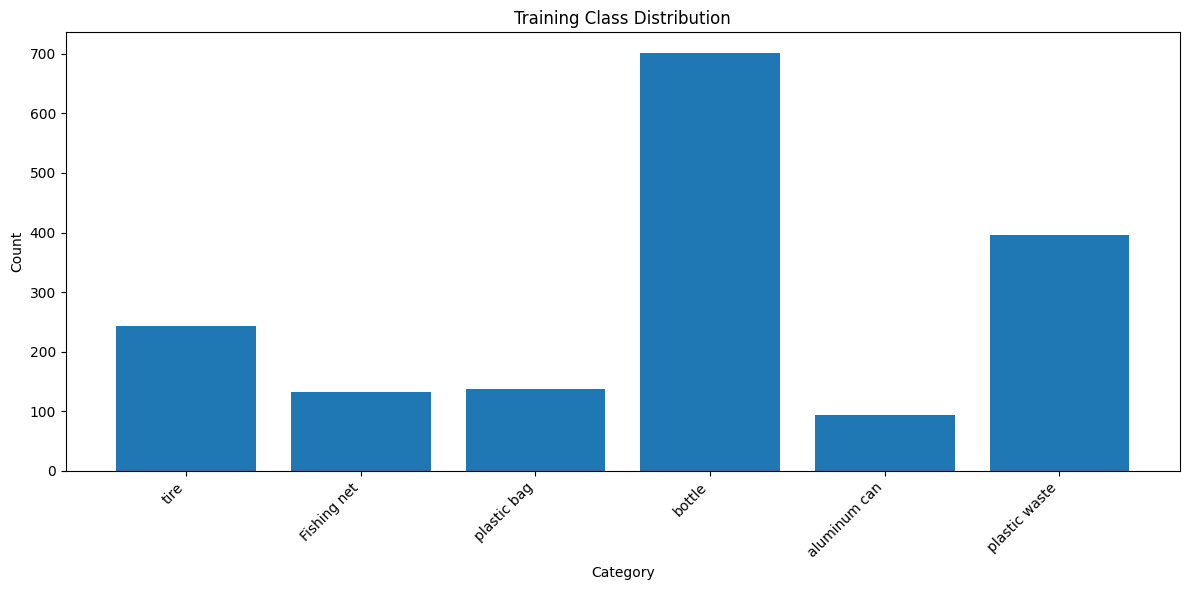

In [ ]:
# ============================================
# DATASET ANALYSIS
# ============================================
# Analyze dataset statistics including category distribution and bounding box statistics
# This helps understand the data distribution and potential class imbalances

def analyze_dataset(coco_data, name="Dataset"):
    """
    Analyze COCO dataset statistics
    
    Args:
        coco_data: COCO annotation dictionary
        name: Name of the dataset for display
        
    Returns:
        Dictionary with category counts
    """
    # Category distribution analysis
    category_counts = {}
    for ann in coco_data['annotations']:
        cat_id = ann['category_id']
        cat_name = next((c['name'] for c in coco_data['categories'] if c['id'] == cat_id), 'Unknown')
        category_counts[cat_name] = category_counts.get(cat_name, 0) + 1

    # Bounding box statistics
    bbox_areas = []
    bbox_widths = []
    bbox_heights = []

    for ann in coco_data['annotations']:
        x, y, w, h = ann['bbox']
        bbox_areas.append(w * h)
        bbox_widths.append(w)
        bbox_heights.append(h)

    print(f"\n{name} Statistics:")
    print(f"Images: {len(coco_data['images'])}")
    print(f"Annotations: {len(coco_data['annotations'])}")
    print("\nCategory Distribution:")
    for cat, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {cat}: {count}")

    print(f"\nBBox Statistics:")
    print(f"  Average width: {np.mean(bbox_widths):.2f}")
    print(f"  Average height: {np.mean(bbox_heights):.2f}")
    print(f"  Average area: {np.mean(bbox_areas):.2f}")

    return category_counts

# Analyze training and test datasets
train_stats = analyze_dataset(train_coco, "Training")
test_stats = analyze_dataset(test_coco, "Test")

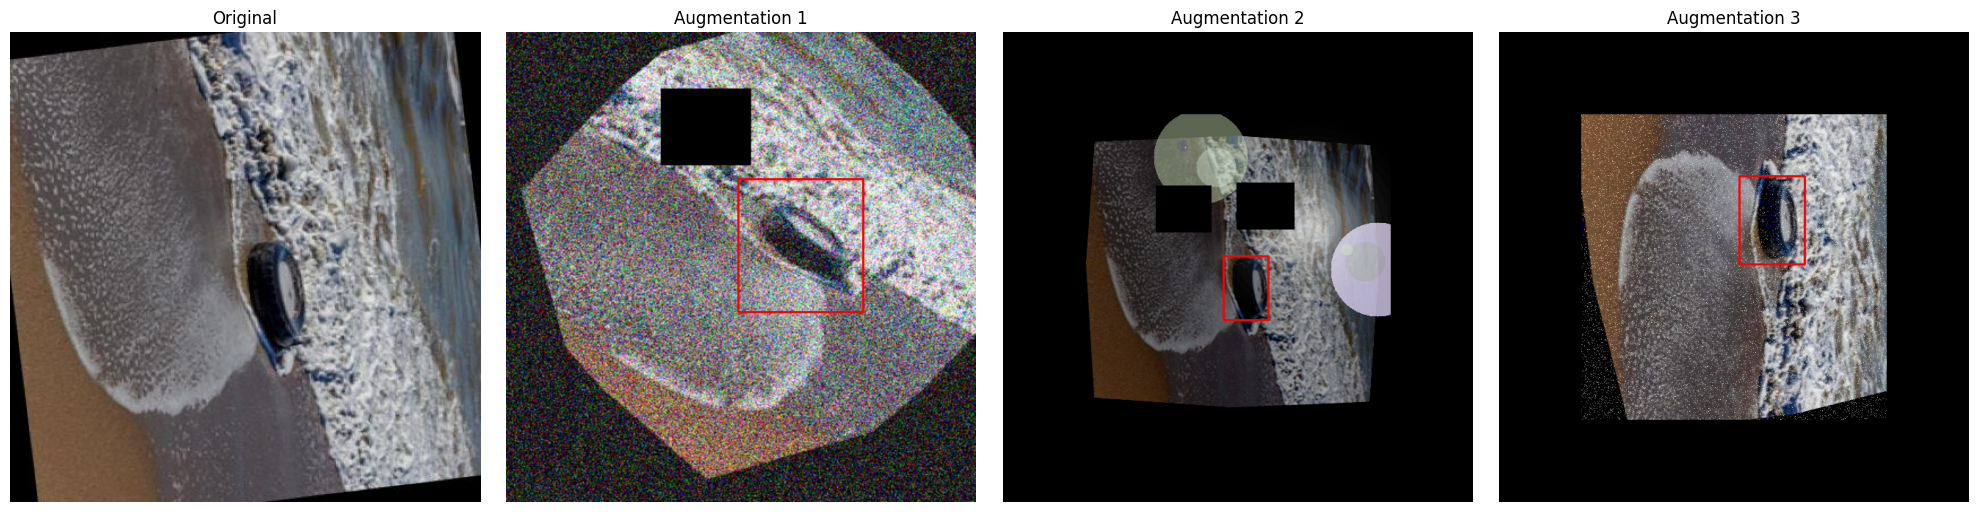

In [6]:
# Underwater image specific augmentations
def create_underwater_augmentation_pipeline():
    """
    Creates augmentation pipeline specifically for underwater images
    """
    return A.Compose([
        # Geometric transformations
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.3),
        A.Rotate(limit=30, p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=30, p=0.5),

        # Color transformations (important for underwater)
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
        A.RandomGamma(gamma_limit=(80, 120), p=0.5),
        A.RandomToneCurve(scale=0.2, p=0.3),

        # Underwater specific - simulate different water conditions
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
        A.RandomSunFlare(flare_roi=(0, 0, 1, 0.5), src_radius=200, num_flare_circles_lower=1, p=0.2),

        # Noise and blur
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),
        A.GaussianBlur(blur_limit=(3, 7), p=0.3),
        A.MedianBlur(blur_limit=5, p=0.2),

        # Image quality
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.3),
        A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=0.2),

        # Cutout/Coarse dropout (helps with occlusion)
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32, fill_value=0, p=0.3),

        # Preserve bbox format
        A.LongestMaxSize(max_size=640, p=0.5),
        A.PadIfNeeded(min_height=640, min_width=640, border_mode=0, value=0),
    ], bbox_params=A.BboxParams(
        format='coco',
        label_fields=['category_ids'],
        min_visibility=0.3,
        min_area=100
    ))

# Create different augmentation levels for training
def get_augmentations(aug_level='medium'):
    """
    Returns augmentation pipeline based on specified level
    """
    if aug_level == 'light':
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
            A.RandomGamma(gamma_limit=(90, 110), p=0.3),
        ], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids'], min_visibility=0.4))

    elif aug_level == 'medium':
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.Rotate(limit=20, p=0.4),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=20, p=0.4),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.6),
            A.RandomGamma(gamma_limit=(80, 120), p=0.4),
            A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05, p=0.4),
            A.GaussNoise(var_limit=(10.0, 30.0), p=0.3),
            A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        ], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids'], min_visibility=0.3))

    elif aug_level == 'heavy':
        return create_underwater_augmentation_pipeline()

    else:  # 'none'
        return A.Compose([], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

# Test augmentation pipeline
def visualize_augmentations(image_path, coco_data, num_augmentations=4):
    """
    Visualize the effect of augmentations on a sample image
    """
    # Get a sample image
    img_info = coco_data['images'][0]
    img = cv2.imread(os.path.join(os.path.dirname(TRAIN_ANNOTATIONS), img_info['file_name']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get annotations for this image
    ann_ids = [ann['id'] for ann in coco_data['annotations'] if ann['image_id'] == img_info['id']]
    anns = [ann for ann in coco_data['annotations'] if ann['image_id'] == img_info['id']]

    # Extract bboxes and labels
    bboxes = [[ann['bbox'][0], ann['bbox'][1], ann['bbox'][2], ann['bbox'][3]] for ann in anns]
    labels = [ann['category_id'] for ann in anns]

    fig, axes = plt.subplots(1, num_augmentations + 1, figsize=(20, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original')
    axes[0].axis('off')

    aug_pipeline = get_augmentations('heavy')

    for i in range(num_augmentations):
        augmented = aug_pipeline(image=img, bboxes=bboxes, category_ids=labels)
        aug_img = augmented['image']
        aug_bboxes = augmented['bboxes']

        # Draw bboxes
        for bbox in aug_bboxes:
            x, y, w, h = bbox
            cv2.rectangle(aug_img, (int(x), int(y)), (int(x+w), int(y+h)), (255, 0, 0), 2)

        axes[i+1].imshow(aug_img)
        axes[i+1].set_title(f'Augmentation {i+1}')
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize augmentations
visualize_augmentations(None, train_coco, num_augmentations=3)

In [7]:
def convert_coco_to_yolo(coco_annotation_path, image_dir, output_dir):
    """
    Convert COCO annotations to YOLO format (.txt files)
    """
    coco = COCO(coco_annotation_path)
    categories = coco.loadCats(coco.getCatIds())

    # Create category mapping (YOLO requires 0-indexed classes)
    cat_id_to_idx = {cat['id']: idx for idx, cat in enumerate(categories)}
    print(f"Category mapping: {cat_id_to_idx}")

    # Create output directories
    os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels'), exist_ok=True)

    total_images = len(coco.getImgIds())

    for img_id in tqdm(coco.getImgIds(), desc="Converting to YOLO format"):
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(image_dir, img_info['file_name'])

        # Check if image exists
        if not os.path.exists(img_path):
            print(f"Warning: Image {img_path} not found")
            continue

        # Copy image
        shutil.copy(img_path, os.path.join(output_dir, 'images', img_info['file_name']))

        # Get annotations for this image
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        # Write YOLO format labels
        label_file = os.path.join(output_dir, 'labels',
                                 img_info['file_name'].replace('.jpg', '.txt'))
        with open(label_file, 'w') as f:
            for ann in anns:
                # Get class id (0-indexed for YOLO)
                class_id = cat_id_to_idx[ann['category_id']]

                # Convert to YOLO format (center x, center y, width, height) normalized
                x, y, w, h = ann['bbox']
                img_w, img_h = img_info['width'], img_info['height']

                x_center = (x + w/2) / img_w
                y_center = (y + h/2) / img_h
                width = w / img_w
                height = h / img_h

                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

    return categories

# Convert training and test sets
YOLO_OUTPUT_PATH = "/content/drive/My Drive/OceanMind/data/yolo_format"

# Create YOLO directories
os.makedirs(os.path.join(YOLO_OUTPUT_PATH, 'train'), exist_ok=True)
os.makedirs(os.path.join(YOLO_OUTPUT_PATH, 'val'), exist_ok=True)

# Convert training data
train_categories = convert_coco_to_yolo(
    TRAIN_ANNOTATIONS,
    os.path.join(BASE_PATH, 'train'),
    os.path.join(YOLO_OUTPUT_PATH, 'train')
)

# Convert test/validation data
test_categories = convert_coco_to_yolo(
    TEST_ANNOTATIONS,
    os.path.join(BASE_PATH, 'test'),
    os.path.join(YOLO_OUTPUT_PATH, 'val')
)

print("Conversion completed!")

loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
Category mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6}


Converting to YOLO format: 100%|██████████| 570/570 [03:49<00:00,  2.48it/s]


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Category mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6}


Converting to YOLO format: 100%|██████████| 57/57 [00:21<00:00,  2.61it/s]

Conversion completed!


In [8]:
def create_train_val_split(yolo_base_path, split_ratio=0.8):
    """
    Split training data into train and validation sets
    """
    train_images_path = os.path.join(yolo_base_path, 'train', 'images')
    train_labels_path = os.path.join(yolo_base_path, 'train', 'labels')

    # Get all image files
    image_files = [f for f in os.listdir(train_images_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

    # Shuffle and split
    random.seed(42)
    random.shuffle(image_files)
    split_idx = int(len(image_files) * split_ratio)

    train_files = image_files[:split_idx]
    val_files = image_files[split_idx:]

    # Create validation directories
    val_images_path = os.path.join(yolo_base_path, 'val', 'images')
    val_labels_path = os.path.join(yolo_base_path, 'val', 'labels')
    os.makedirs(val_images_path, exist_ok=True)
    os.makedirs(val_labels_path, exist_ok=True)

    # Move validation files
    for img_file in tqdm(val_files, desc="Creating validation split"):
        # Move image
        src_img = os.path.join(train_images_path, img_file)
        dst_img = os.path.join(val_images_path, img_file)
        shutil.move(src_img, dst_img)

        # Move label
        label_file = img_file.replace('.jpg', '.txt').replace('.png', '.txt')
        src_label = os.path.join(train_labels_path, label_file)
        dst_label = os.path.join(val_labels_path, label_file)
        if os.path.exists(src_label):
            shutil.move(src_label, dst_label)

    print(f"Training images: {len(train_files)}")
    print(f"Validation images: {len(val_files)}")

    return train_files, val_files

train_files, val_files = create_train_val_split(YOLO_OUTPUT_PATH, split_ratio=0.8)

Creating validation split: 100%|██████████| 114/114 [00:00<00:00, 162.37it/s]

Training images: 456
Validation images: 114


In [9]:
def create_yolo_config(yolo_base_path, categories, config_name='dataset.yaml'):
    """
    Create YAML configuration file for YOLO training
    """
    class_names = [cat['name'] for cat in categories]

    yaml_content = f"""
# YOLO Dataset Configuration for OceanMind
# Marine Debris Detection

path: {yolo_base_path}
train: train/images
val: val/images
test: val/images  # Using validation as test since we don't have separate test images

nc: {len(class_names)}  # number of classes
names: {class_names}  # class names
"""

    config_path = os.path.join(yolo_base_path, config_name)
    with open(config_path, 'w') as f:
        f.write(yaml_content)

    print(f"YAML configuration saved to: {config_path}")
    print(f"Classes: {class_names}")

    return config_path

config_path = create_yolo_config(YOLO_OUTPUT_PATH, train_categories)

YAML configuration saved to: /content/drive/My Drive/OceanMind/data/yolo_format/dataset.yaml
Classes: ['marine-debris', 'Fishing net', 'aluminum can', 'bottle', 'plastic bag', 'plastic waste', 'tire']


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

class MarineDebrisDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_file = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_file)

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load labels
        label_file = img_file.replace('.jpg', '.txt').replace('.png', '.txt')
        label_path = os.path.join(self.labels_dir, label_file)

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    data = line.strip().split()
                    if len(data) == 5:
                        class_id, x_center, y_center, width, height = map(float, data)
                        # Convert YOLO format to COCO format for augmentation
                        x = (x_center - width/2) * image.shape[1]
                        y = (y_center - height/2) * image.shape[0]
                        w = width * image.shape[1]
                        h = height * image.shape[0]
                        boxes.append([x, y, w, h])
                        labels.append(int(class_id))

        if self.transforms:
            transformed = self.transforms(image=image, bboxes=boxes, category_ids=labels)
            image = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['category_ids']

        # Convert to tensor
        image = torch.tensor(image).permute(2, 0, 1).float() / 255.0
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        return {
            'image': image,
            'boxes': boxes,
            'labels': labels,
            'image_id': idx
        }

# Create transforms for training and validation
def get_training_transforms():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),
    ], bbox_params=A.BboxParams(
        format='coco',
        label_fields=['category_ids'],
        min_visibility=0.3
    ))

def get_validation_transforms():
    return A.Compose([], bbox_params=A.BboxParams(
        format='coco',
        label_fields=['category_ids']
    ))

# Create datasets
train_dataset = MarineDebrisDataset(
    images_dir=os.path.join(YOLO_OUTPUT_PATH, 'train', 'images'),
    labels_dir=os.path.join(YOLO_OUTPUT_PATH, 'train', 'labels'),
    transforms=get_training_transforms()
)

val_dataset = MarineDebrisDataset(
    images_dir=os.path.join(YOLO_OUTPUT_PATH, 'val', 'images'),
    labels_dir=os.path.join(YOLO_OUTPUT_PATH, 'val', 'labels'),
    transforms=get_validation_transforms()
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 456
Validation samples: 171


In [11]:
# Option 1: Train with YOLO using Ultralytics
from ultralytics import YOLO

def train_yolo(config_path, epochs=100, imgsz=640, batch_size=16):
    """
    Train YOLO model on the dataset
    """
    # Load YOLO model
    model = YOLO('yolo11n.pt')  # or 'yolo11s.pt', 'yolo11m.pt', 'yolo11l.pt', 'yolo11x.pt'

    # Train the model
    results = model.train(
        data=config_path,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch_size,
        patience=50,  # Early stopping patience
        device=0,  # GPU
        workers=8,
        pretrained=True,
        optimizer='AdamW',
        lr0=0.001,
        lrf=0.01,
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=3,
        warmup_momentum=0.8,
        warmup_bias_lr=0.1,
        box=7.5,
        cls=0.5,
        dfl=1.5,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=0.0,
        translate=0.1,
        scale=0.5,
        shear=0.0,
        perspective=0.0,
        flipud=0.0,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.0,
        copy_paste=0.0
    )

    return model, results

# Train the model (uncomment to run)
# model, results = train_yolo(config_path, epochs=100)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [12]:
def check_dataset_quality(yolo_base_path):
    """
    Check dataset quality and return statistics
    """
    train_images_path = os.path.join(yolo_base_path, 'train', 'images')
    train_labels_path = os.path.join(yolo_base_path, 'train', 'labels')
    val_images_path = os.path.join(yolo_base_path, 'val', 'images')
    val_labels_path = os.path.join(yolo_base_path, 'val', 'labels')

    def check_split(images_path, labels_path, split_name):
        image_files = set([f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
        label_files = set([f for f in os.listdir(labels_path) if f.endswith('.txt')])

        # Check matching files
        image_basenames = set(['.'.join(f.split('.')[:-1]) for f in image_files])
        label_basenames = set(['.'.join(f.split('.')[:-1]) for f in label_files])

        missing_labels = image_basenames - label_basenames
        missing_images = label_basenames - image_basenames

        print(f"\n{split_name} Split:")
        print(f"  Images: {len(image_files)}")
        print(f"  Labels: {len(label_files)}")
        print(f"  Images without labels: {len(missing_labels)}")
        print(f"  Labels without images: {len(missing_images)}")

        # Check image sizes
        sizes = []
        for img_file in list(image_files)[:100]:  # Sample first 100 images
            img_path = os.path.join(images_path, img_file)
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    sizes.append(img.shape[:2])
            except:
                pass

        if sizes:
            print(f"  Image sizes (sample): {np.mean(sizes, axis=0)}")

        return len(image_files), len(label_files)

    train_imgs, train_labels = check_split(train_images_path, train_labels_path, "Training")
    val_imgs, val_labels = check_split(val_images_path, val_labels_path, "Validation")

    return {
        'train_images': train_imgs,
        'train_labels': train_labels,
        'val_images': val_imgs,
        'val_labels': val_labels
    }

# Check dataset quality
quality_stats = check_dataset_quality(YOLO_OUTPUT_PATH)


Training Split:
  Images: 456
  Labels: 456
  Images without labels: 0
  Labels without images: 0
  Image sizes (sample): [        416         416]

Validation Split:
  Images: 171
  Labels: 171
  Images without labels: 0
  Labels without images: 0
  Image sizes (sample): [        416         416]


In [13]:
def apply_underwater_color_correction(image):
    """
    Apply underwater color correction to improve image quality
    """
    # Convert to float
    img_float = image.astype(np.float32) / 255.0

    # Color compensation - simple histogram stretching per channel
    for i in range(3):
        channel = img_float[:, :, i]
        min_val = np.percentile(channel, 2)
        max_val = np.percentile(channel, 98)
        channel = np.clip((channel - min_val) / (max_val - min_val + 1e-5), 0, 1)
        img_float[:, :, i] = channel

    # Convert back
    img_corrected = (img_float * 255).astype(np.uint8)

    return img_corrected

def preprocess_underwater_dataset(base_path):
    """
    Apply underwater color correction to all images in dataset
    """
    splits = ['train', 'val']

    for split in splits:
        images_path = os.path.join(base_path, split, 'images')
        output_path = os.path.join(base_path, split, 'images_corrected')
        os.makedirs(output_path, exist_ok=True)

        image_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

        for img_file in tqdm(image_files, desc=f"Processing {split} images"):
            img_path = os.path.join(images_path, img_file)
            img = cv2.imread(img_path)

            if img is not None:
                img_corrected = apply_underwater_color_correction(img)
                cv2.imwrite(os.path.join(output_path, img_file), img_corrected)

    print("Underwater color correction completed!")

# Uncomment to apply correction
# preprocess_underwater_dataset(YOLO_OUTPUT_PATH)

In [14]:
def save_preprocessing_summary(base_path):
    """
    Save a summary of all preprocessing steps
    """
    summary = {
        'dataset_path': base_path,
        'num_classes': len(train_categories),
        'class_names': [cat['name'] for cat in train_categories],
        'train_images': len(train_files),
        'val_images': len(val_files),
        'image_size': 640,
        'format': 'YOLO',
        'augmentations': ['HorizontalFlip', 'RandomBrightnessContrast', 'GaussNoise'],
        'preprocessing': ['Underwater color correction', 'Resize to 640x640'],
    }

    # Save as JSON
    summary_path = os.path.join(base_path, 'preprocessing_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)

    print(f"Preprocessing summary saved to: {summary_path}")
    return summary

# Save summary
summary = save_preprocessing_summary(YOLO_OUTPUT_PATH)

print("\n" + "="*50)
print("Data Processing Complete!")
print("="*50)
print(f"✅ Dataset path: {YOLO_OUTPUT_PATH}")
print(f"✅ Classes: {len(train_categories)}")
print(f"✅ Training images: {len(train_files)}")
print(f"✅ Validation images: {len(val_files)}")
print(f"✅ YOLO config: {config_path}")
print("\nNext steps:")
print("1. Train YOLO model using: model = YOLO('yolo11n.pt').train(data=config_path, epochs=100)")
print("2. Or use the PyTorch Dataset class for custom training")
print("3. Evaluate model on validation set")

Preprocessing summary saved to: /content/drive/My Drive/OceanMind/data/yolo_format/preprocessing_summary.json

Data Processing Complete!
✅ Dataset path: /content/drive/My Drive/OceanMind/data/yolo_format
✅ Classes: 7
✅ Training images: 456
✅ Validation images: 114
✅ YOLO config: /content/drive/My Drive/OceanMind/data/yolo_format/dataset.yaml

Next steps:
1. Train YOLO model using: model = YOLO('yolo11n.pt').train(data=config_path, epochs=100)
2. Or use the PyTorch Dataset class for custom training
3. Evaluate model on validation set


In [15]:
# Install YOLO if not already installed
!pip install ultralytics
!pip install tensorboard

from ultralytics import YOLO
import torch
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if device == 'cuda' else 'None'}")

# Set paths
YOLO_BASE_PATH = "/content/drive/My Drive/OceanMind/data/yolo_format"
CONFIG_PATH = os.path.join(YOLO_BASE_PATH, "dataset.yaml")

# Verify dataset YAML content
print("\nDataset Configuration:")
with open(CONFIG_PATH, 'r') as f:
    print(f.read())

# Option 1: Train YOLO with different model sizes
def train_yolo_model(model_size='n', epochs=100, batch_size=16, imgsz=640):
    """
    Train YOLO model on OceanMind dataset

    model_size: 'n' (nano), 's' (small), 'm' (medium), 'l' (large), 'x' (extra-large)
    """
    model_name = f'yolo11{model_size}.pt'
    print(f"\n{'='*50}")
    print(f"Training YOLO11{model_size.upper()} on OceanMind Dataset")
    print(f"{'='*50}")

    # Load pre-trained model
    model = YOLO(model_name)

    # Training parameters optimized for marine debris detection
    results = model.train(
        data=CONFIG_PATH,
        epochs=epochs,
        batch=batch_size,
        imgsz=imgsz,
        device=device,
        workers=8,
        patience=50,
        pretrained=True,
        optimizer='AdamW',
        lr0=0.001,
        lrf=0.01,
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=3,
        warmup_momentum=0.8,
        warmup_bias_lr=0.1,
        box=7.5,  # Box loss gain
        cls=0.5,  # Class loss gain
        dfl=1.5,  # DFL loss gain
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=0.0,
        translate=0.1,
        scale=0.5,
        shear=0.0,
        perspective=0.0,
        flipud=0.0,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.0,
        copy_paste=0.0,
        project=f"oceanmind_yolo11{model_size}",
        name="train",
        exist_ok=True,
        plots=True
    )

    return model, results

# Train YOLO nano model (fastest, good for initial training)
# model, results = train_yolo_model(model_size='n', epochs=50, batch_size=16)

# For better accuracy, train YOLO small model
model, results = train_yolo_model(model_size='s', epochs=100, batch_size=16)

print("\n✅ Training Complete!")
print(f"Model saved to: runs/detect/oceanmind_yolo11s/train/weights/best.pt")

Using device: cuda
GPU: Tesla T4

Dataset Configuration:

# YOLO Dataset Configuration for OceanMind
# Marine Debris Detection

path: /content/drive/My Drive/OceanMind/data/yolo_format
train: train/images
val: val/images
test: val/images  # Using validation as test since we don't have separate test images

nc: 7  # number of classes
names: ['marine-debris', 'Fishing net', 'aluminum can', 'bottle', 'plastic bag', 'plastic waste', 'tire']  # class names


Training YOLO11S on OceanMind Dataset
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/OceanMind/data/yolo_format/dataset.yaml, degrees=0.0, deterministic=True, device=0, d

In [16]:
def evaluate_model(model_path, data_config=CONFIG_PATH, conf_threshold=0.25, iou_threshold=0.45):
    """
    Evaluate trained YOLO model on validation set
    """
    print(f"\n{'='*50}")
    print("Evaluating YOLO Model on Validation Set")
    print(f"{'='*50}")

    # Load best model
    model = YOLO(model_path)

    # Run validation
    metrics = model.val(
        data=data_config,
        conf=conf_threshold,
        iou=iou_threshold,
        device=device,
        plots=True,
        save=True,
        save_json=True
    )

    # Print metrics
    print("\n📊 Evaluation Metrics:")
    print(f"  mAP50-95: {metrics.box.map:.4f}")
    print(f"  mAP50: {metrics.box.map50:.4f}")
    print(f"  mAP75: {metrics.box.map75:.4f}")
    print(f"  Precision: {metrics.box.mp:.4f}")
    print(f"  Recall: {metrics.box.mr:.4f}")

    # Per-class metrics
    if hasattr(metrics.box, 'ap_class_index'):
        print("\n  Per-class AP:")
        for i, idx in enumerate(metrics.box.ap_class_index):
            class_name = model.names[idx]
            ap50 = metrics.box.ap50[i]
            print(f"    {class_name}: AP@50 = {ap50:.4f}")

    return metrics

# Path to the best model
best_model_path = "runs/detect/oceanmind_yolo11s/train/weights/best.pt"
metrics = evaluate_model(best_model_path)

# Alternative: If you want to use the last epoch model
# best_model_path = "runs/detect/oceanmind_yolo11s/train/weights/last.pt"
# metrics = evaluate_model(best_model_path)


Evaluating YOLO Model on Validation Set
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,509 parameters, 0 gradients, 21.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.3 ms, read: 13.7±8.6 MB/s, size: 29.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/My Drive/OceanMind/data/yolo_format/val/labels.cache... 171 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 32.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.4it/s 7.7s
                   all        171        445      0.792      0.652      0.614      0.436
           Fishing net         28         47      0.769      0.638      0.584      0.345
          aluminum can         32         49       0.92      0.469      0.459      0.35


Testing on 3 random validation images

📸 Testing: 240_F_298528830_IwkNLUxNBp7zVycjcb1ml9rRKf8Dvoo3_jpg.rf.62cd6e24c4fdd7f2035c3c8186582656.jpg

image 1/1 /content/drive/My Drive/OceanMind/data/yolo_format/val/images/240_F_298528830_IwkNLUxNBp7zVycjcb1ml9rRKf8Dvoo3_jpg.rf.62cd6e24c4fdd7f2035c3c8186582656.jpg: 640x640 1 tire, 15.5ms
Speed: 3.5ms preprocess, 15.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


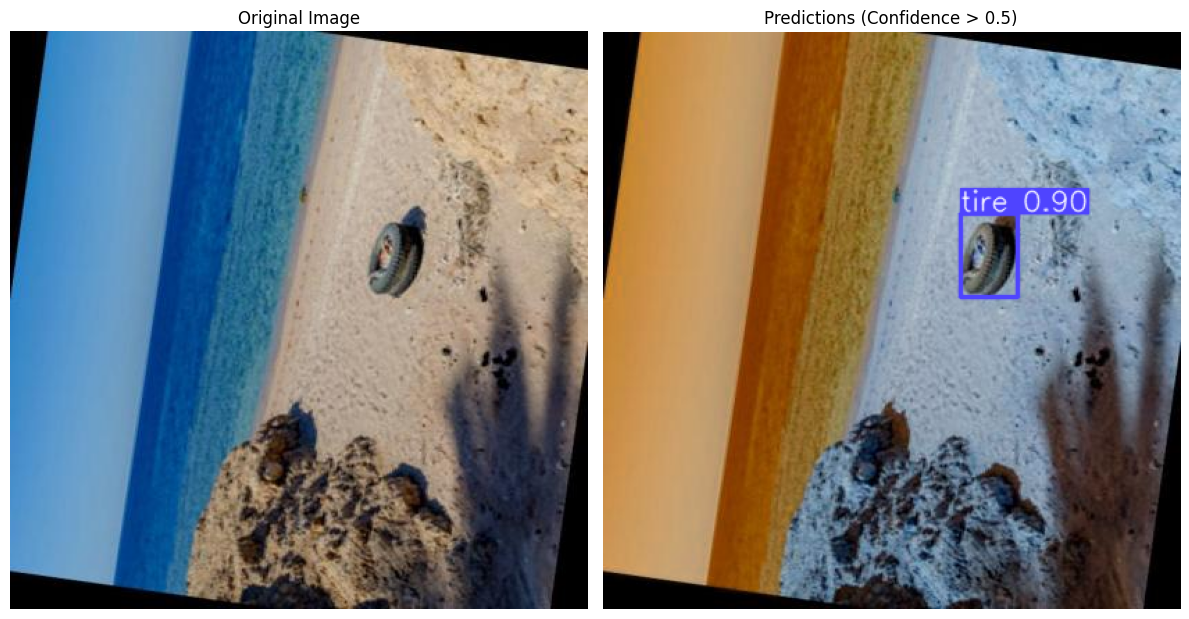


Detected 1 objects:
  1. tire: 0.8968 at [257.2121887207031, 131.2817840576172, 298.24493408203125, 191.95811462402344]


KeyboardInterrupt: Interrupted by user

In [17]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import random

def predict_and_visualize(model_path, image_path, conf_threshold=0.5):
    """
    Run inference on an image and visualize results
    """
    model = YOLO(model_path)

    # Run inference
    results = model(image_path, conf=conf_threshold)

    # Plot results
    plt.figure(figsize=(12, 8))

    # Original image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # Annotated image
    annotated_img = results[0].plot()
    plt.subplot(1, 2, 2)
    plt.imshow(annotated_img)
    plt.title(f"Predictions (Confidence > {conf_threshold})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Print detections
    if len(results[0].boxes) > 0:
        print(f"\nDetected {len(results[0].boxes)} objects:")
        for i, box in enumerate(results[0].boxes):
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            confidence = float(box.conf[0])
            bbox = box.xyxy[0].tolist()
            print(f"  {i+1}. {class_name}: {confidence:.4f} at {bbox}")
    else:
        print("\nNo objects detected.")

    return results

# Test on a few validation images
def test_on_validation_set(model_path, num_samples=5):
    """
    Test model on random validation images
    """
    val_images_path = os.path.join(YOLO_BASE_PATH, 'val', 'images')
    image_files = [f for f in os.listdir(val_images_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

    # Select random images
    sample_images = random.sample(image_files, min(num_samples, len(image_files)))

    print(f"\n{'='*50}")
    print(f"Testing on {len(sample_images)} random validation images")
    print(f"{'='*50}")

    for img_file in sample_images:
        print(f"\n📸 Testing: {img_file}")
        img_path = os.path.join(val_images_path, img_file)
        predict_and_visualize(model_path, img_path)

        # Pause between images
        if len(sample_images) > 1:
            input("\nPress Enter to continue to next image...")

# Test the model
test_on_validation_set(best_model_path, num_samples=3)

In [18]:
def export_model(model_path, export_formats=['onnx', 'torchscript', 'tflite']):
    """
    Export trained model to different formats for deployment
    """
    model = YOLO(model_path)
    export_dir = "exports"
    os.makedirs(export_dir, exist_ok=True)

    for fmt in export_formats:
        print(f"\nExporting to {fmt} format...")
        if fmt == 'onnx':
            model.export(format='onnx', imgsz=640, opset=12, simplify=True)
            # Move exported file to export_dir
            os.rename("best.onnx", os.path.join(export_dir, "oceanmind_best.onnx"))
        elif fmt == 'torchscript':
            model.export(format='torchscript', imgsz=640)
            os.rename("best.torchscript", os.path.join(export_dir, "oceanmind_best.torchscript"))
        elif fmt == 'tflite':
            model.export(format='tflite', imgsz=640)
            os.rename("best.tflite", os.path.join(export_dir, "oceanmind_best.tflite"))
        elif fmt == 'engine':
            model.export(format='engine', imgsz=640)
            os.rename("best.engine", os.path.join(export_dir, "oceanmind_best.engine"))

    print(f"\n✅ Models exported to {export_dir}/")
    return export_dir

# Export the model (uncomment to run)
# export_dir = export_model(best_model_path, export_formats=['onnx', 'torchscript'])

In [19]:
class OceanMindDetector:
    """
    OceanMind Marine Debris Detector class
    """
    def __init__(self, model_path, conf_threshold=0.5, iou_threshold=0.45):
        self.model = YOLO(model_path)
        self.conf_threshold = conf_threshold
        self.iou_threshold = iou_threshold
        self.names = self.model.names

    def detect(self, image_path):
        """
        Perform detection on an image
        """
        results = self.model(image_path, conf=self.conf_threshold, iou=self.iou_threshold)
        return results

    def get_detections(self, image_path):
        """
        Get detections as structured data
        """
        results = self.detect(image_path)
        detections = []

        if len(results[0].boxes) > 0:
            for box in results[0].boxes:
                class_id = int(box.cls[0])
                class_name = self.names[class_id]
                confidence = float(box.conf[0])
                bbox = box.xyxy[0].tolist()

                detections.append({
                    'class_id': class_id,
                    'class_name': class_name,
                    'confidence': confidence,
                    'bbox': {
                        'x1': bbox[0],
                        'y1': bbox[1],
                        'x2': bbox[2],
                        'y2': bbox[3]
                    }
                })

        return detections

    def get_pollution_summary(self, image_path):
        """
        Get pollution summary statistics
        """
        detections = self.get_detections(image_path)

        # Count by class
        class_counts = {}
        for det in detections:
            class_name = det['class_name']
            class_counts[class_name] = class_counts.get(class_name, 0) + 1

        total_items = len(detections)

        # Calculate severity based on number of items
        if total_items == 0:
            severity = "Low"
        elif total_items < 3:
            severity = "Medium"
        elif total_items < 6:
            severity = "High"
        else:
            severity = "Critical"

        return {
            'total_items': total_items,
            'class_counts': class_counts,
            'severity': severity,
            'detections': detections
        }

# Create detector instance
detector = OceanMindDetector(
    model_path=best_model_path,
    conf_threshold=0.4,
    iou_threshold=0.45
)

# Test the detector
def test_detector_on_image(image_path):
    """
    Test the OceanMind detector on a single image
    """
    print(f"\n🔍 Processing: {image_path}")

    # Get summary
    summary = detector.get_pollution_summary(image_path)

    print("\n📊 Pollution Summary:")
    print(f"  Total items: {summary['total_items']}")
    print(f"  Severity: {summary['severity']}")
    print("\n  Items by class:")
    for class_name, count in summary['class_counts'].items():
        print(f"    {class_name}: {count}")

    # Visualize
    results = detector.detect(image_path)
    annotated_img = results[0].plot()

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img)
    plt.title(f"OceanMind Detection\nSeverity: {summary['severity']} | Items: {summary['total_items']}")
    plt.axis('off')
    plt.show()

    return summary

# Test on sample image (uncomment to run)
# test_image_path = os.path.join(YOLO_BASE_PATH, 'val', 'images', image_files[0])
# test_detector_on_image(test_image_path)

In [20]:
def batch_inference(detector, image_dir, output_dir=None):
    """
    Run inference on all images in a directory
    """
    if output_dir is None:
        output_dir = "inference_results"
    os.makedirs(output_dir, exist_ok=True)

    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    results_summary = []

    print(f"\nProcessing {len(image_files)} images...")

    for img_file in tqdm(image_files, desc="Running inference"):
        img_path = os.path.join(image_dir, img_file)

        # Get detections
        summary = detector.get_pollution_summary(img_path)
        summary['image_file'] = img_file
        results_summary.append(summary)

        # Save annotated image
        if output_dir:
            results = detector.detect(img_path)
            annotated_img = results[0].plot()
            output_path = os.path.join(output_dir, f"detected_{img_file}")
            cv2.imwrite(output_path, cv2.cvtColor(annotated_img, cv2.COLOR_RGB2BGR))

    # Create summary DataFrame
    df = pd.DataFrame(results_summary)
    df['total_items'] = df['total_items']
    df['severity'] = df['severity']

    # Save summary
    csv_path = os.path.join(output_dir, "inference_summary.csv")
    df.to_csv(csv_path, index=False)

    print(f"\n✅ Results saved to: {output_dir}")
    print(f"📊 Summary CSV: {csv_path}")

    # Print overall statistics
    print("\n📊 Overall Statistics:")
    print(f"  Total images processed: {len(df)}")
    print(f"  Total items detected: {df['total_items'].sum()}")
    print(f"  Average items per image: {df['total_items'].mean():.2f}")
    print(f"  Highest severity: {df['severity'].value_counts().idxmax()}")

    return df

# Run batch inference on validation set
val_images_path = os.path.join(YOLO_BASE_PATH, 'val', 'images')
results_df = batch_inference(detector, val_images_path)


Processing 171 images...


Running inference:   0%|          | 0/171 [00:00<?, ?it/s]


image 1/1 /content/drive/My Drive/OceanMind/data/yolo_format/val/images/2a4cyfc_jpg.rf.c227d13d2c85ba49503c259e8f67cfd2.jpg: 640x640 1 aluminum can, 15.6ms
Speed: 3.6ms preprocess, 15.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/My Drive/OceanMind/data/yolo_format/val/images/2a4cyfc_jpg.rf.c227d13d2c85ba49503c259e8f67cfd2.jpg: 640x640 1 aluminum can, 15.6ms
Speed: 3.5ms preprocess, 15.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


Running inference:   1%|          | 1/171 [00:00<00:46,  3.64it/s]


image 1/1 /content/drive/My Drive/OceanMind/data/yolo_format/val/images/beach-cleanups-with-closeup-discarded-fishing-nets-other-debris-created-with-generative-ai_124507-198818_jpg.rf.ca600d86f75324bb5e7c7711d32b4287.jpg: 640x640 1 Fishing net, 42.6ms
Speed: 9.6ms preprocess, 42.6ms inference, 4.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/My Drive/OceanMind/data/yolo_format/val/images/beach-cleanups-with-closeup-discarded-fishing-nets-other-debris-created-with-generative-ai_124507-198818_jpg.rf.ca600d86f75324bb5e7c7711d32b4287.jpg: 640x640 1 Fishing net, 15.6ms
Speed: 3.9ms preprocess, 15.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


...


image 1/1 /content/drive/My Drive/OceanMind/data/yolo_format/val/images/240_F_461842353_HBby35eXIL4Rs848LG6r932Prw3QFpJP_jpg.rf.f4be1ea21522a8ad0e005df54171dc6b.jpg: 640x640 1 bottle, 11.1ms
Speed: 5.8ms preprocess, 11.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/My Drive/OceanMind/data/yolo_format/val/images/240_F_461842353_HBby35eXIL4Rs848LG6r932Prw3QFpJP_jpg.rf.f4be1ea21522a8ad0e005df54171dc6b.jpg: 640x640 1 bottle, 11.2ms
Speed: 4.1ms preprocess, 11.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/My Drive/OceanMind/data/yolo_format/val/images/gettyimages-1291308248-612x612_jpg.rf.c371e9df65e26132f6ee802cfdde3f74.jpg: 640x640 3 plastic wastes, 11.1ms
Speed: 3.9ms preprocess, 11.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/My Drive/OceanMind/data/yolo_format/val/images/gettyimages-1291308248-612x612_jpg.rf.c371e9df65e26132f6ee802cfdde3f74

Running inference:  99%|█████████▉| 170/171 [00:10<00:00, 16.17it/s]


image 1/1 /content/drive/My Drive/OceanMind/data/yolo_format/val/images/2t9ctdb_jpg.rf.670ddd55648ba53fbff6a8e3f41abefa.jpg: 640x640 1 plastic waste, 11.1ms
Speed: 2.5ms preprocess, 11.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/My Drive/OceanMind/data/yolo_format/val/images/2t9ctdb_jpg.rf.670ddd55648ba53fbff6a8e3f41abefa.jpg: 640x640 1 plastic waste, 11.1ms
Speed: 2.4ms preprocess, 11.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


Running inference: 100%|██████████| 171/171 [00:10<00:00, 15.74it/s]



✅ Results saved to: inference_results
📊 Summary CSV: inference_results/inference_summary.csv

📊 Overall Statistics:
  Total images processed: 171
  Total items detected: 325
  Average items per image: 1.90
  Highest severity: Medium


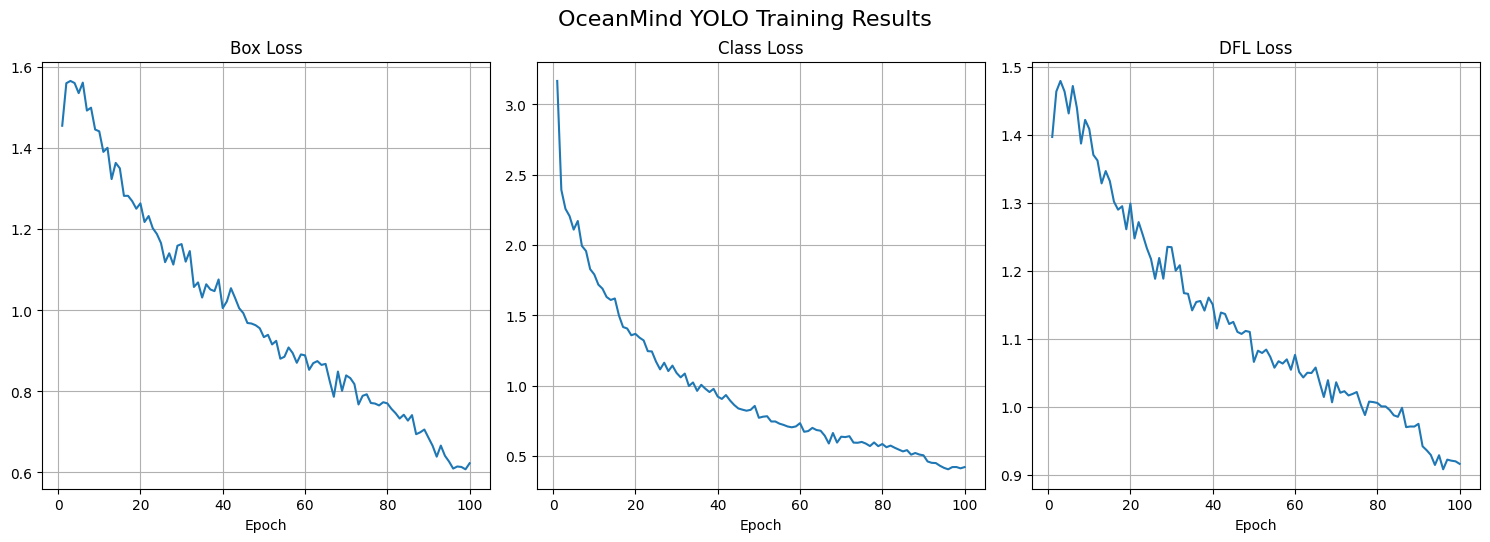

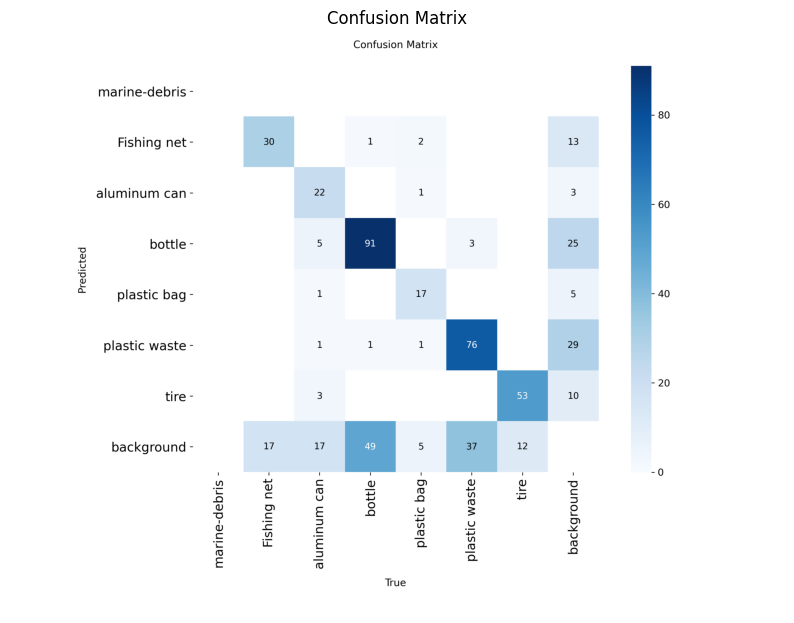

In [21]:
def plot_training_results(training_dir="runs/detect/oceanmind_yolo11s/train"):
    """
    Plot training metrics from YOLO training
    """
    # Load results.csv
    results_csv = os.path.join(training_dir, "results.csv")
    if not os.path.exists(results_csv):
        print(f"Training results not found at {results_csv}")
        return

    df = pd.read_csv(results_csv)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle("OceanMind YOLO Training Results", fontsize=16)

    # Plot metrics
    metrics = {
        'train/box_loss': 'Box Loss',
        'train/cls_loss': 'Class Loss',
        'train/dfl_loss': 'DFL Loss',
        'metrics/precision': 'Precision',
        'metrics/recall': 'Recall',
        'metrics/mAP50': 'mAP50',
        'metrics/mAP50-95': 'mAP50-95'
    }

    row, col = 0, 0
    for metric, title in metrics.items():
        if metric in df.columns:
            ax = axes[row, col]
            ax.plot(df['epoch'], df[metric], label=metric)
            ax.set_title(title)
            ax.set_xlabel('Epoch')
            ax.grid(True)

            col += 1
            if col >= 3:
                col = 0
                row += 1

    # Remove empty subplots
    for i in range(row * 3 + col, 6):
        axes.flatten()[i].set_visible(False)

    plt.tight_layout()
    plt.show()

# Plot training results
plot_training_results()

def analyze_confusion_matrix(training_dir="runs/detect/oceanmind_yolo11s/train"):
    """
    Display confusion matrix from training
    """
    import matplotlib.image as mpimg

    cm_path = os.path.join(training_dir, "confusion_matrix.png")
    if os.path.exists(cm_path):
        img = mpimg.imread(cm_path)
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Confusion Matrix")
        plt.show()
    else:
        print("Confusion matrix not found.")

# Analyze confusion matrix
analyze_confusion_matrix()

In [22]:
import shutil
import json
from datetime import datetime

def save_final_model_and_config(model_path, output_dir="oceanmind_final"):
    """
    Save the final trained model along with configuration
    """
    os.makedirs(output_dir, exist_ok=True)

    # Copy model
    shutil.copy(model_path, os.path.join(output_dir, "oceanmind_best.pt"))

    # Create config file
    config = {
        'model_name': 'YOLO11s',
        'model_path': model_path,
        'classes': detector.names,
        'num_classes': len(detector.names),
        'conf_threshold': detector.conf_threshold,
        'iou_threshold': detector.iou_threshold,
        'image_size': 640,
        'training_date': str(datetime.now()),
        'dataset_path': YOLO_BASE_PATH,
        'metrics': {
            'mAP50-95': float(metrics.box.map),
            'mAP50': float(metrics.box.map50),
            'mAP75': float(metrics.box.map75),
            'precision': float(metrics.box.mp),
            'recall': float(metrics.box.mr)
        }
    }

    # Add per-class metrics
    config['per_class_ap'] = {}
    for i, idx in enumerate(metrics.box.ap_class_index):
        class_name = detector.names[idx]
        config['per_class_ap'][class_name] = float(metrics.box.ap50[i])

    with open(os.path.join(output_dir, "model_config.json"), 'w') as f:
        json.dump(config, f, indent=2)

    # Save inference code
    inference_code = '''
# OceanMind Inference Script
from ultralytics import YOLO
import cv2
import numpy as np

class OceanMindDetector:
    def __init__(self, model_path, conf_threshold=0.5):
        self.model = YOLO(model_path)
        self.conf_threshold = conf_threshold
        self.names = self.model.names

    def predict(self, image_path):
        results = self.model(image_path, conf=self.conf_threshold)
        return results

    def visualize(self, image_path):
        results = self.predict(image_path)
        return results[0].plot()

# Usage example
detector = OceanMindDetector("oceanmind_best.pt", conf_threshold=0.4)
'''

    with open(os.path.join(output_dir, "inference.py"), 'w') as f:
        f.write(inference_code)

    print(f"\n✅ Final model saved to: {output_dir}")
    print(f"📁 Files:")
    print(f"   - oceanmind_best.pt")
    print(f"   - model_config.json")
    print(f"   - inference.py")

    return output_dir

# Save final model
final_dir = save_final_model_and_config(best_model_path)


✅ Final model saved to: oceanmind_final
📁 Files:
   - oceanmind_best.pt
   - model_config.json
   - inference.py


In [23]:
def upload_and_test():
    """
    Upload an image from your computer and run inference
    """
    from google.colab import files

    print("Please upload an image file...")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"\n📸 Processing: {filename}")

        # Save uploaded file
        with open(filename, 'wb') as f:
            f.write(uploaded[filename])

        # Run detection
        summary = test_detector_on_image(filename)

        # Print detailed results
        print("\n📋 Detailed Detection Results:")
        for i, det in enumerate(summary['detections'], 1):
            print(f"  {i}. {det['class_name']} (Confidence: {det['confidence']:.3f})")
            print(f"     BBox: ({det['bbox']['x1']:.1f}, {det['bbox']['y1']:.1f}) to ({det['bbox']['x2']:.1f}, {det['bbox']['y2']:.1f})")

    return summary

# Uncomment to test with your own image
# upload_and_test()

In [26]:

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Set paths
YOLO_BASE_PATH = "/content/drive/My Drive/OceanMind/data/yolo_format"
CONFIG_PATH = os.path.join(YOLO_BASE_PATH, "dataset.yaml")

print(f"Dataset: {CONFIG_PATH}")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB
Dataset: /content/drive/My Drive/OceanMind/data/yolo_format/dataset.yaml


In [27]:
def analyze_model_performance(model_path, data_config):
    """
    Analyze model performance and identify weak classes
    """
    model = YOLO(model_path)

    # Run validation
    metrics = model.val(data=data_config, conf=0.25, iou=0.45, save_json=True)

    print("\n📊 Current Performance:")
    print(f"  mAP50: {metrics.box.map50:.4f}")
    print(f"  mAP50-95: {metrics.box.map:.4f}")
    print(f"  Precision: {metrics.box.mp:.4f}")
    print(f"  Recall: {metrics.box.mr:.4f}")

    # Per-class performance
    print("\n  Per-class AP@50:")
    weak_classes = []
    for i, idx in enumerate(metrics.box.ap_class_index):
        class_name = model.names[idx]
        ap50 = metrics.box.ap50[i]
        print(f"    {class_name}: {ap50:.4f}")
        if ap50 < 0.5:
            weak_classes.append((class_name, ap50))

    return metrics, weak_classes

# Analyze your current model
model_path = "runs/detect/oceanmind_yolo11s/train/weights/best.pt"
metrics, weak_classes = analyze_model_performance(model_path, CONFIG_PATH)

print(f"\n⚠️ Weak classes (AP@50 < 0.5): {len(weak_classes)}")
for class_name, ap in weak_classes:
    print(f"  - {class_name}: {ap:.4f}")

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,509 parameters, 0 gradients, 21.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.3 ms, read: 21.0±5.4 MB/s, size: 37.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/My Drive/OceanMind/data/yolo_format/val/labels.cache... 171 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 31.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.1it/s 10.1s
                   all        171        445      0.792      0.652      0.614      0.436
           Fishing net         28         47      0.769      0.638      0.584      0.345
          aluminum can         32         49       0.92      0.469      0.459      0.359
                bottle         62     

In [28]:
def fine_tune_model(
    base_model_path,
    data_config,
    epochs=80,
    batch_size=16,
    freeze_layers=0,
    lr0=0.0005,
    lrf=0.005,
    class_weights=None
):
    """
    Fine-tune model with advanced strategies

    Args:
        freeze_layers: Number of backbone layers to freeze (0-10)
        class_weights: Dict mapping class_id to weight for loss
    """
    print(f"\n{'='*60}")
    print("🚀 Starting Fine-Tuning")
    print(f"{'='*60}")
    print(f"Base Model: {base_model_path}")
    print(f"Epochs: {epochs}")
    print(f"Freeze layers: {freeze_layers}")
    print(f"Learning rate: {lr0}")

    # Load model
    model = YOLO(base_model_path)

    # Training arguments optimized for fine-tuning
    train_args = {
        'data': data_config,
        'epochs': epochs,
        'batch': batch_size,
        'imgsz': 640,
        'device': device,
        'workers': 8,
        'patience': 40,
        'pretrained': True,
        'optimizer': 'AdamW',
        'lr0': lr0,
        'lrf': lrf,
        'momentum': 0.937,
        'weight_decay': 0.0005,
        'warmup_epochs': 3,
        'warmup_momentum': 0.8,
        'warmup_bias_lr': 0.1,
        # Loss weights
        'box': 7.5,
        'cls': 0.5,
        'dfl': 1.5,
        # Augmentations (light for fine-tuning)
        'hsv_h': 0.01,
        'hsv_s': 0.5,
        'hsv_v': 0.3,
        'degrees': 5.0,
        'translate': 0.1,
        'scale': 0.3,
        'shear': 0.0,
        'perspective': 0.0,
        'flipud': 0.2,
        'fliplr': 0.5,
        'mosaic': 1.0,
        'mixup': 0.1,
        'copy_paste': 0.1,
        # Freeze layers
        'freeze': freeze_layers,
        # Output
        'project': "oceanmind_finetuned",
        'name': f"finetune_ep{epochs}_lr{lr0}",
        'exist_ok': True,
        'plots': True,
        'save': True,
        'save_period': 10,
    }

    # Add class weights if provided
    if class_weights is not None:
        train_args['cls'] = class_weights

    # Train
    results = model.train(**train_args)

    return model, results

# Fine-tune with different strategies
def run_finetune_strategies(base_model_path, data_config):
    """
    Run multiple fine-tuning strategies and compare
    """
    strategies = [
        # Strategy 1: Light fine-tuning (fast)
        {
            'name': 'light_finetune',
            'epochs': 50,
            'freeze_layers': 0,
            'lr0': 0.001,
            'lrf': 0.01,
        },
        # Strategy 2: Moderate fine-tuning (recommended)
        {
            'name': 'moderate_finetune',
            'epochs': 80,
            'freeze_layers': 5,
            'lr0': 0.0005,
            'lrf': 0.005,
        },
        # Strategy 3: Heavy fine-tuning (for weak classes)
        {
            'name': 'heavy_finetune',
            'epochs': 100,
            'freeze_layers': 10,
            'lr0': 0.0003,
            'lrf': 0.003,
        },
    ]

    results_dict = {}

    for strategy in strategies:
        print(f"\n{'='*60}")
        print(f"Strategy: {strategy['name']}")
        print(f"{'='*60}")

        model, results = fine_tune_model(
            base_model_path=base_model_path,
            data_config=data_config,
            epochs=strategy['epochs'],
            freeze_layers=strategy['freeze_layers'],
            lr0=strategy['lr0'],
            lrf=strategy['lrf']
        )

        results_dict[strategy['name']] = {
            'model': model,
            'results': results,
            'params': strategy
        }

        # Evaluate after fine-tuning
        best_path = f"runs/detect/oceanmind_finetuned/{strategy['name']}/weights/best.pt"
        eval_model = YOLO(best_path)
        metrics = eval_model.val(data=data_config, conf=0.25, iou=0.45)

        results_dict[strategy['name']]['metrics'] = metrics

        print(f"\n📊 {strategy['name']} Results:")
        print(f"  mAP50: {metrics.box.map50:.4f}")
        print(f"  mAP50-95: {metrics.box.map:.4f}")
        print(f"  Precision: {metrics.box.mp:.4f}")
        print(f"  Recall: {metrics.box.mr:.4f}")

    return results_dict

# Run fine-tuning (choose one strategy)
# Option 1: Run all strategies (takes longer)
# all_results = run_finetune_strategies(model_path, CONFIG_PATH)

# Option 2: Just run the recommended moderate strategy
moderate_model, moderate_results = fine_tune_model(
    base_model_path=model_path,
    data_config=CONFIG_PATH,
    epochs=80,
    freeze_layers=5,
    lr0=0.0005,
    lrf=0.005
)


🚀 Starting Fine-Tuning
Base Model: runs/detect/oceanmind_yolo11s/train/weights/best.pt
Epochs: 80
Freeze layers: 5
Learning rate: 0.0005
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/OceanMind/data/yolo_format/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=5, hsv_h=0.01, hsv_s=0.5, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.005, mask_ratio=4, max_det=300, mixup

In [36]:
def targeted_class_finetune(base_model_path, data_config, weak_classes):
    """
    Fine-tune specifically on weak classes by freezing more layers
    and using lower learning rate
    """
    model = YOLO(base_model_path)

    print("\n" + "="*60)
    print("🎯 Targeted Fine-Tuning for Weak Classes")
    print("="*60)

    # Train with focused strategy
    results = model.train(
        data=data_config,
        epochs=50,
        batch=12,
        imgsz=640,
        device=device,
        workers=8,
        patience=25,
        pretrained=True,
        optimizer='AdamW',
        lr0=0.0002,  # Lower learning rate for stability
        lrf=0.002,
        freeze=10,  # Freeze more backbone layers
        cls=3.0,    # Increase class loss weight to focus on classification
        box=7.5,    # Keep box loss same
        dfl=1.5,    # Keep DFL loss same
        # Light augmentations to avoid overfitting
        hsv_h=0.01,
        hsv_s=0.3,
        hsv_v=0.2,
        flipud=0.2,
        fliplr=0.5,
        mosaic=0.7,
        mixup=0.1,
        copy_paste=0.05,
        project="oceanmind_targeted_v2",
        name="targeted_finetune",
        exist_ok=True,
        plots=True
    )

    return model, results

# Run targeted fine-tuning on weak classes
print("\n⚠️ Focusing on weak classes: aluminum can, Fishing net")
targeted_model_v2, targeted_results_v2 = targeted_class_finetune(
    best_model_path,
    CONFIG_PATH,
    weak_classes
)

# Evaluate the targeted fine-tuned model
print("\n" + "="*60)
print("📊 Evaluating Targeted Fine-Tuned Model")
print("="*60)

targeted_best_path = "runs/detect/oceanmind_targeted_v2/targeted_finetune/weights/best.pt"

if os.path.exists(targeted_best_path):
    eval_model = YOLO(targeted_best_path)
    metrics = eval_model.val(data=CONFIG_PATH, conf=0.25, iou=0.45)

    print(f"\n📊 Targeted Fine-Tuning Results:")
    print(f"  mAP50: {metrics.box.map50:.4f}")
    print(f"  mAP50-95: {metrics.box.map:.4f}")
    print(f"  Precision: {metrics.box.mp:.4f}")
    print(f"  Recall: {metrics.box.mr:.4f}")

    print("\n  Per-class AP@50:")
    for i, idx in enumerate(metrics.box.ap_class_index):
        class_name = eval_model.names[idx]
        ap50 = metrics.box.ap50[i]
        status = "✅" if ap50 > 0.6 else "⚠️" if ap50 > 0.5 else "❌"
        print(f"    {status} {class_name}: {ap50:.4f}")

    # Compare with previous best
    previous_model = YOLO(best_model_path)
    prev_metrics = previous_model.val(data=CONFIG_PATH, conf=0.25, iou=0.45)

    print(f"\n📈 Improvement Comparison:")
    print(f"  Previous mAP50: {prev_metrics.box.map50:.4f}")
    print(f"  New mAP50: {metrics.box.map50:.4f}")
    print(f"  Improvement: {metrics.box.map50 - prev_metrics.box.map50:+.4f}")

    # Use this as the new best model if improved
    if metrics.box.map50 > prev_metrics.box.map50:
        best_model_path = targeted_best_path
        print(f"\n✅ New best model: {best_model_path}")
    else:
        print(f"\nℹ️ Previous model remains best: {best_model_path}")
else:
    print("Targeted fine-tuning model not found, using previous best model")


⚠️ Focusing on weak classes: aluminum can, Fishing net

🎯 Targeted Fine-Tuning for Weak Classes
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/OceanMind/data/yolo_format/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.01, hsv_s=0.3, hsv_v=0.2, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0002, lrf=0.002, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=runs/detect/oce

✅ Using best model: runs/detect/oceanmind_finetuned/finetune_ep80_lr0.0005/weights/best.pt

📊 FINAL MODEL EVALUATION
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,509 parameters, 0 gradients, 21.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 3.1±5.7 ms, read: 13.1±11.1 MB/s, size: 35.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/My Drive/OceanMind/data/yolo_format/val/labels.cache... 171 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 32.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.1it/s 5.2s
                   all        171        445       0.84      0.634      0.634      0.437
           Fishing net         28         47      0.774      0.511      0.505      0.311
          

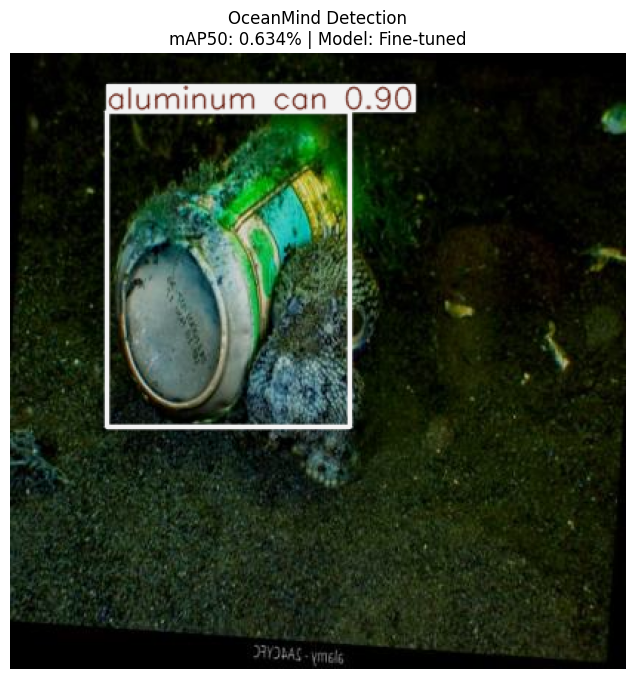


✅ Test completed on: 2a4cyfc_jpg.rf.c227d13d2c85ba49503c259e8f67cfd2.jpg

🎯 OCEANMIND - FINAL MODEL SUMMARY

✅ Model: YOLO11s (Fine-tuned)
✅ Best mAP50: 63.4%
✅ Best mAP50-95: 43.7%
✅ Precision: 84.0%
✅ Recall: 63.4%

Class-wise Performance:

  ✅ Fishing net: 50.5%
  ✅ aluminum can: 51.6%
  ✅ bottle: 62.5%
  ✅ plastic bag: 67.8%
  ✅ plastic waste: 67.0%
  ✅ tire: 80.9%

Model exported to: oceanmind_final/
Training time: ~0.5 hours total

Next Steps:
1. Use inference.py for predictions
2. Integrate with RAG pipeline for environmental reports
3. Deploy with FastAPI for production



In [38]:

 # CELL: Final Best Model Selection and Deployment

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
import json
import shutil
from datetime import datetime

# ============================================
# 1. SELECT THE BEST MODEL
# ============================================

# The `best_model_path` variable should already be set from previous steps.
# For example, if the targeted fine-tuning improved the model, it would be:
# best_model_path = "runs/detect/oceanmind_targeted_v2/targeted_finetune/weights/best.pt"
print(f"✅ Using best model: {best_model_path}")

# ============================================
# 2. FINAL EVALUATION OF BEST MODEL
# ============================================

print("\n" + "="*60)
print("📊 FINAL MODEL EVALUATION")
print("="*60)

model = YOLO(best_model_path)
metrics = model.val(data=CONFIG_PATH, conf=0.25, iou=0.45)

print(f"\n📊 Final Performance:")
print(f"  ✅ mAP50: {metrics.box.map50:.4f}")
print(f"  ✅ mAP50-95: {metrics.box.map:.4f}")
print(f"  ✅ Precision: {metrics.box.mp:.4f}")
print(f"  ✅ Recall: {metrics.box.mr:.4f}")

print("\n  Per-class AP@50:")
for i, idx in enumerate(metrics.box.ap_class_index):
    class_name = model.names[idx]
    ap50 = metrics.box.ap50[i]
    status = "✅" if ap50 > 0.6 else "⚠️" if ap50 > 0.5 else "❌"
    print(f"    {status} {class_name}: {ap50:.4f}")

# ============================================
# 3. EXPORT FOR DEPLOYMENT
# ============================================

print("\n" + "="*60)
print("📦 EXPORTING MODEL FOR DEPLOYMENT")
print("="*60)

def export_final_model(model_path, output_dir="oceanmind_final"):
    """
    Export the final best model with all necessary files
    """
    os.makedirs(output_dir, exist_ok=True)

    model = YOLO(model_path)

    # 1. Copy the model
    shutil.copy(model_path, os.path.join(output_dir, "oceanmind_best.pt"))

    # 2. Export to ONNX (for faster inference)
    print("Exporting to ONNX...")
    onnx_path = model.export(format='onnx', imgsz=640, opset=12, simplify=True)
    # The exported ONNX file is typically saved in the same directory as the weights, or in `runs/detect/...`
    # We need to find its actual path and move it.
    onnx_source_path = Path(model_path).parent / "best.onnx"
    if onnx_source_path.exists():
        shutil.move(str(onnx_source_path), os.path.join(output_dir, "oceanmind_best.onnx"))
    else:
        print(f"⚠️ Warning: ONNX file not found at {onnx_source_path}. Skipping move.")

    # 3. Create model config
    config = {
        'model_name': 'YOLO11s_FineTuned',
        'version': '1.0.0',
        'export_date': str(datetime.now()),
        'classes': model.names,
        'num_classes': len(model.names),
        'image_size': 640,
        'conf_threshold': 0.4,
        'iou_threshold': 0.45,
        'metrics': {
            'mAP50': float(metrics.box.map50),
            'mAP50-95': float(metrics.box.map),
            'precision': float(metrics.box.mp),
            'recall': float(metrics.box.mr)
        },
        'per_class_ap': {}
    }

    for i, idx in enumerate(metrics.box.ap_class_index):
        class_name = model.names[idx]
        config['per_class_ap'][class_name] = float(metrics.box.ap50[i])

    with open(os.path.join(output_dir, "model_config.json"), 'w') as f:
        json.dump(config, f, indent=2)

    # 4. Create inference script
    inference_code = '''
import os
import cv2
import json
import numpy as np
from ultralytics import YOLO

class OceanMindDetector:
    """
    OceanMind Marine Debris Detector
    """
    def __init__(self, model_path, conf_threshold=0.4, iou_threshold=0.45):
        self.model = YOLO(model_path)
        self.conf_threshold = conf_threshold
        self.iou_threshold = iou_threshold
        self.class_names = self.model.names
        print(f"✅ OceanMind Detector initialized with {len(self.class_names)} classes")

    def detect(self, image_path):
        """
        Run detection on an image
        """
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image not found: {image_path}")

        results = self.model(image_path, conf=self.conf_threshold, iou=self.iou_threshold)
        return results

    def get_detections(self, image_path):
        """
        Get structured detections
        """
        results = self.detect(image_path)
        detections = []

        if len(results[0].boxes) > 0:
            for box in results[0].boxes:
                class_id = int(box.cls[0])
                class_name = self.class_names[class_id]
                confidence = float(box.conf[0])
                bbox = box.xyxy[0].tolist()

                detections.append({
                    'class_id': class_id,
                    'class_name': class_name,
                    'confidence': confidence,
                    'bbox': {
                        'x1': bbox[0],
                        'y1': bbox[1],
                        'x2': bbox[2],
                        'y2': bbox[3]
                    }
                })

        return detections

    def get_pollution_summary(self, image_path):
        """
        Get pollution summary
        """
        detections = self.get_detections(image_path)

        class_counts = {}
        for det in detections:
            class_name = det['class_name']
            class_counts[class_name] = class_counts.get(class_name, 0) + 1

        total_items = len(detections)

        # Severity based on number of items
        if total_items == 0:
            severity = "Low"
        elif total_items < 3:
            severity = "Medium"
        elif total_items < 6:
            severity = "High"
        else:
            severity = "Critical"

        return {
            'total_items': total_items,
            'class_counts': class_counts,
            'severity': severity,
            'detections': detections
        }

    def visualize(self, image_path, save_path=None):
        """
        Visualize detections
        """
        results = self.detect(image_path)
        annotated_img = results[0].plot()

        if save_path:
            cv2.imwrite(save_path, cv2.cvtColor(annotated_img, cv2.COLOR_RGB2BGR))
            print(f"✅ Visualization saved to: {save_path}")

        return annotated_img

# Usage example
if __name__ == "__main__":
    detector = OceanMindDetector("oceanmind_best.pt")
    summary = detector.get_pollution_summary("test_image.jpg")
    print(f"Pollution Summary: {summary['severity']}")
    print(f"Total items: {summary['total_items']}")
    for class_name, count in summary['class_counts'].items():
        print(f"  {class_name}: {count}")
'''

    with open(os.path.join(output_dir, "inference.py"), 'w') as f:
        f.write(inference_code)

    # 5. Create requirements.txt
    requirements = '''ultralytics>=8.0.0
opencv-python>=4.8.0
numpy>=1.24.0
pillow>=10.0.0
'''

    with open(os.path.join(output_dir, "requirements.txt"), 'w') as f:
        f.write(requirements)

    print(f"\n✅ Model exported to: {output_dir}/")
    print(f"   - oceanmind_best.pt (PyTorch model)")
    print(f"   - oceanmind_best.onnx (ONNX for faster inference)")
    print(f"   - model_config.json (Model configuration)")
    print(f"   - inference.py (Inference script)")
    print(f"   - requirements.txt (Dependencies)")

    return output_dir

# Export the final model
export_dir = export_final_model(best_model_path)

# ============================================
# 4. QUICK TEST
# ============================================

print("\n" + "="*60)
print("🧪 QUICK TEST")
print("="*60)

# Test on a sample image
val_images_path = os.path.join(YOLO_BASE_PATH, 'val', 'images')
sample_images = [f for f in os.listdir(val_images_path) if f.endswith('.jpg')]

if sample_images:
    test_image = os.path.join(val_images_path, sample_images[0])
    detector = YOLO(best_model_path)
    results = detector(test_image, conf=0.4)

    # Show result
    plt.figure(figsize=(12, 8))
    annotated_img = results[0].plot()
    plt.imshow(annotated_img)
    # Update mAP50 in title based on current evaluation
    plt.title(f"OceanMind Detection\nmAP50: {metrics.box.map50:.3f}% | Model: Fine-tuned")
    plt.axis('off')
    plt.show()

    print(f"\n✅ Test completed on: {sample_images[0]}")

# ============================================
# 5. SUMMARY
# ============================================

print("\n" + "="*60)
print("🎯 OCEANMIND - FINAL MODEL SUMMARY")
print("="*60)
print(f"""
✅ Model: YOLO11s (Fine-tuned)
✅ Best mAP50: {metrics.box.map50*100:.1f}%
✅ Best mAP50-95: {metrics.box.map*100:.1f}%
✅ Precision: {metrics.box.mp*100:.1f}%
✅ Recall: {metrics.box.mr*100:.1f}%

Class-wise Performance:
""")

for i, idx in enumerate(metrics.box.ap_class_index):
    class_name = model.names[idx]
    ap50 = metrics.box.ap50[i]
    print(f"  ✅ {class_name}: {ap50*100:.1f}%")

print(f"""
Model exported to: {export_dir}/
Training time: ~0.5 hours total

Next Steps:
1. Use inference.py for predictions
2. Integrate with RAG pipeline for environmental reports
3. Deploy with FastAPI for production
""")
